In [80]:
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import random

### File Reading

In [81]:
labels = []
numbers = []

with open(os.path.join(os.getcwd(), 'data/MNISTnumLabels5000_balanced.txt'), 'r+') as f:
    lines = f.readlines()
    for line in lines:
        labels.append(int(line))

with open(os.path.join(os.getcwd(), 'data/MNISTnumImages5000_balanced.txt'), 'r+') as f:
    lines = f.readlines()
    for line in lines:
        ind_line = line.split('\t')
        ind_line = [float(i) for i in ind_line]

        numbers.append(ind_line)
    

labels = np.array(labels)
numbers = np.array(numbers)

0


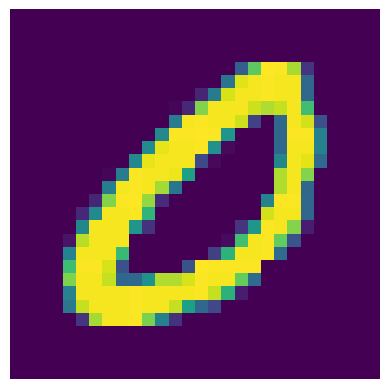

In [82]:
index = random.randint(0, 4999)

example_number = numbers[index]
example_label = labels[index]
matrix = example_number.reshape(28, 28).T

print(example_label)
plt.imshow(matrix)
plt.axis('off')
plt.show()

In [83]:
train_set = []
train_labels = []

test_set = []
test_labels = []

digits = {d: 0 for d in range(0, 10)}

for i in range(len(numbers)):
    label = labels[i]  # get the digit for this image
    
    if label in digits and digits[label] < 400:
        train_set.append(numbers[i])
        train_labels.append(label)
        digits[label] += 1
    else:
        test_set.append(numbers[i])
        test_labels.append(label)
        digits[label] += 1


train_set = np.array(train_set)
test_set = np.array(test_set)
train_labels = np.array(train_labels)
test_labels = np.array(test_labels)
# normalizing the datasets
train_set = train_set.astype(np.float32)/255.0
test_set = test_set.astype(np.float32)/255.0

combined_train_data = list(zip(train_labels, train_set))
random.shuffle(combined_train_data)

combined_test_data = list(zip(test_labels, test_set))
random.shuffle(combined_test_data)

print(len(combined_train_data), len(combined_test_data))

4000 1000


7


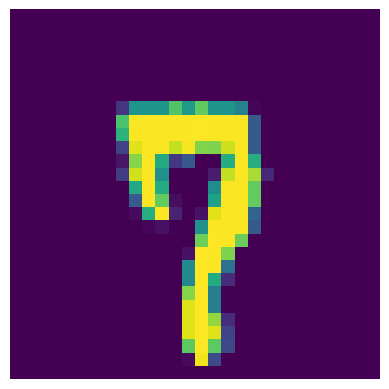

In [84]:
index = random.randint(0, 3999)

example_number = train_set[index]
example_label = train_labels[index]
matrix = example_number.reshape(28, 28).T

print(example_label)
plt.imshow(matrix)
plt.axis('off')
plt.show()

In [85]:
train_set.shape

(4000, 784)

In [86]:
m, n = train_set.shape

X_train, X_test = train_set, test_set
Y_train, Y_test = train_labels, test_labels

_, m_train = X_train.shape
_, m_test = X_test.shape

In [87]:
X_train.shape

(4000, 784)

In [88]:
# Shuffle training set
perm_train = np.random.permutation(X_train.shape[0])  # columns = samples
X_train = X_train[perm_train]
Y_train = np.array(Y_train)[perm_train]  

# Shuffle test set
perm_test = np.random.permutation(X_test.shape[0])
X_test = X_test[perm_test]
Y_test = np.array(Y_test)[perm_test]

X_train.shape, Y_train.shape

((4000, 784), (4000,))

### Implementing the Neural Network

In [89]:
def init_params(input_size=784, hidden_size=128, output_size=10):
    W1 = np.random.randn(input_size, hidden_size) * 0.01
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, output_size) * 0.01
    b2 = np.zeros((1, output_size))
    return W1, b1, W2, b2

# Rectified Linear Unit
def ReLU(x):
    return x * (x > 0)

def deriv_ReLU(Y):
    return Y > 0

# Softmax activation function
def softmax(x):
    e = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e / np.sum(e, axis=1, keepdims=True)

# Tanh function
def tanh(x):
    return (2 / (1 + np.exp(-2 * np.clip(x, -100, 100)))) - 1

# Derivative of Tanh function
def deriv_tanh(Y):
    return 1 - np.clip(Y, -100, 100)**2

# Encodes scores into 0s or 1s
def encode_answers(Y):
    m = Y.size
    one_hot = np.zeros((m, 10))
    one_hot[np.arange(m), Y] = 1
    return one_hot

def forward(W1, b1, W2, b2, x):
    Z1 = x @ W1 + b1
    A1 = np.tanh(Z1)             # Hidden layer activation with tanh
    Z2 = A1 @ W2 + b2      # Output layer linear transformation
    A2 = softmax(Z2)          # Output layer activation with softmax
    return Z1, A1, Z2, A2

def backward(Z1, A1, A2, W2, X, Y):
    m = Y.size
    Y_onehot = encode_answers(Y)

    dZ2 = A2 - Y_onehot                # (batch,10)
    dW2 = A1.T @ dZ2 / m               # (128,10)
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    dZ1 = dZ2 @ W2.T * (1 - A1**2)     # tanh’(Z1)
    dW1 = X.T @ dZ1 / m                # (784,128)
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    return dW1, db1, dW2, db2

# Updating weights and biases for a 2-layer neural network
def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, lr):
    W1 = W1 - lr * dW1
    b1 = b1 - lr * db1
    W2 = W2 - lr * dW2
    b2 = b2 - lr * db2
    return W1, b1, W2, b2

In [90]:
def calculate_confidence(Pred, Expect):
    # Pred shape: (batch, 10)
    predictions = np.argmax(Pred, axis=1)
    return np.mean(predictions == Expect)

def gradient_descent(X, Y, epochs, lr=0.01, batch_size=64):
    W1, b1, W2, b2 = init_params()
    m = X.shape[0]   # number of samples

    for epoch in range(epochs):

        # ---- Shuffle every epoch ----
        perm = np.random.permutation(m)
        X = X[perm]
        Y = Y[perm]

        # ---- Mini-batch loop ----
        for i in range(0, m, batch_size):
            X_batch = X[i:i+batch_size]
            Y_batch = Y[i:i+batch_size]

            # Forward and backward on batch
            Z1, A1, Z2, A2 = forward(W1, b1, W2, b2, X_batch)
            dW1, db1, dW2, db2 = backward(Z1, A1, A2, W2, X_batch, Y_batch)

            # Parameter update
            W1, b1, W2, b2 = update_params(
                W1, b1, W2, b2,
                dW1, db1, dW2, db2,
                lr
            )

        # ---- Print confidence occasionally ----
        if epoch % 10 == 0:
            _, _, _, A2_full = forward(W1, b1, W2, b2, X)
            conf = calculate_confidence(A2_full, Y)
            print(f"Epoch {epoch}: Confidence = {conf:.4f}")

    return W1, b1, W2, b2


In [ ]:
W1, b1, W2, b2= gradient_descent(X_train, Y_train, 25000, 0.01)

Epoch 0: Confidence = 0.1398
Epoch 10: Confidence = 0.1000
Epoch 20: Confidence = 0.1000
Epoch 30: Confidence = 0.1000
Epoch 40: Confidence = 0.1000
Epoch 50: Confidence = 0.1003
Epoch 60: Confidence = 0.1000
Epoch 70: Confidence = 0.1000
Epoch 80: Confidence = 0.1000
Epoch 90: Confidence = 0.1000
Epoch 100: Confidence = 0.1000
Epoch 110: Confidence = 0.1000
Epoch 120: Confidence = 0.1035
Epoch 130: Confidence = 0.1003
Epoch 140: Confidence = 0.1000
Epoch 150: Confidence = 0.1000
Epoch 160: Confidence = 0.1052
Epoch 170: Confidence = 0.1000
Epoch 180: Confidence = 0.1020
Epoch 190: Confidence = 0.1475
Epoch 200: Confidence = 0.1673
Epoch 210: Confidence = 0.1000
Epoch 220: Confidence = 0.1378
Epoch 230: Confidence = 0.1000
Epoch 240: Confidence = 0.1000
Epoch 250: Confidence = 0.1000
Epoch 260: Confidence = 0.1017
Epoch 270: Confidence = 0.1512
Epoch 280: Confidence = 0.1000
Epoch 290: Confidence = 0.1000
Epoch 300: Confidence = 0.1358
Epoch 310: Confidence = 0.1000
Epoch 320: Confiden

KeyboardInterrupt: 

In [ ]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward(W1, b1, W2, b2, X)    # A2 is our output layer
    predictions = np.argmax(A2, 0)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_test[:, index, None]     # Printing out the images
    prediction = make_predictions(X_test[:, index, None], W1, b1, W2, b2)
    label = Y_test[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    current_image = current_image.reshape((28, 28)).T * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  [7]
Label:  7


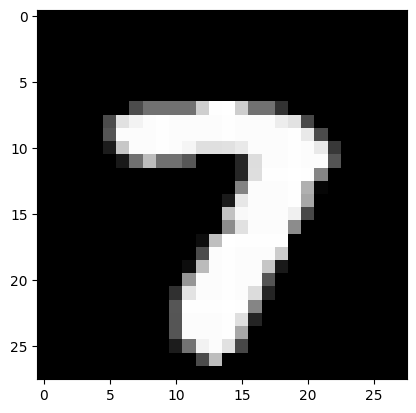

Prediction:  [2]
Label:  2


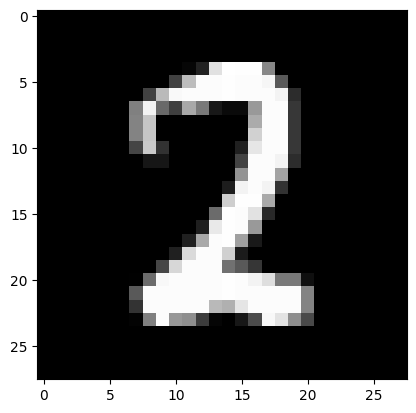

Prediction:  [8]
Label:  8


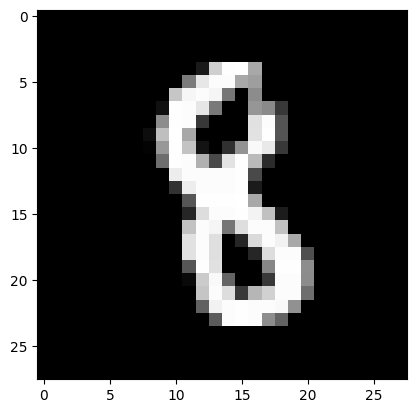

Prediction:  [2]
Label:  2


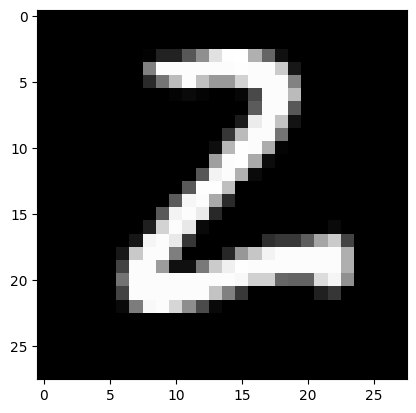

Prediction:  [6]
Label:  6


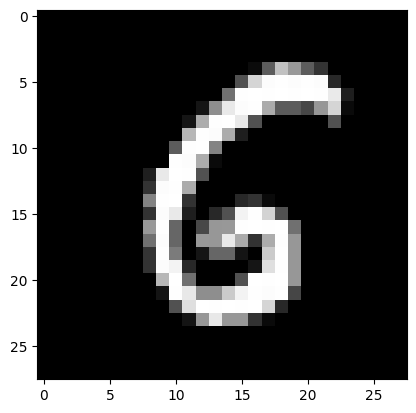

In [ ]:
for _ in range(5):
    rand = random.randint(0, m_test - 1)
    test_prediction(rand, W1, b1, W2, b2)

In [ ]:
# Calculate overall model accuracy
total = m_test  
corrects = 0    

# Iterate over each test example
for i in range(total):
    prediction = make_predictions(X_test[:, i, None], W1, b1, W2, b2)
    
    if prediction == Y_test[i]:  
        corrects += 1  

# Print overall accuracy
print(f"Overall accuracy: {corrects / total:.4f}")  


Overall accuracy: 0.8080


In [ ]:
np.savez("model_weights.npz", W1=W1, b1=b1, W2=W2, b2=b2)

In [ ]:
data = np.load("model_weights.npz")
W1_copy = data["W1"]
b1_copy = data["b1"]
W2_copy = data["W2"]
b2_copy = data["b2"]

In [ ]:
W1 == W1_copy

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])